In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

In [2]:
using CairoMakie
CairoMakie.activate!()
using InteractiveDynamics
using Agents

```gaml
/**
* Name: Predator agents (parent species)
* Author:
* Description: 5th part of the tutorial : Predator Prey
* Tags: inheritance
*/
model prey_predator

global {
	int nb_preys_init <- 200;
	int nb_predators_init <- 20;
	float prey_max_energy <- 1.0;
	float prey_max_transfert <- 0.1;
	float prey_energy_consum <- 0.05;
	float predator_max_energy <- 1.0;
	float predator_energy_transfert <- 0.5;
	float predator_energy_consum <- 0.02;
	int nb_preys -> {length(prey)};
	int nb_predators -> {length(predator)};

	init {
		create prey number: nb_preys_init;
		create predator number: nb_predators_init;
	}

}

species generic_species {
	float size <- 1.0;
	rgb color;
	float max_energy;
	float max_transfert;
	float energy_consum;
	vegetation_cell my_cell <- one_of(vegetation_cell);
	float energy <- rnd(max_energy) update: energy - energy_consum max: max_energy;

	init {
		location <- my_cell.location;
	}

	reflex basic_move {
		my_cell <- one_of(my_cell.neighbors2);
		location <- my_cell.location;
	}

	reflex eat {
		energy <- energy + energy_from_eat();
	}

	reflex die when: energy <= 0 {
		do die;
	}

	float energy_from_eat {
		return 0.0;
	}

	aspect base {
		draw circle(size) color: color;
	}

}

species prey parent: generic_species {
	rgb color <- #blue;
	float max_energy <- prey_max_energy;
	float max_transfert <- prey_max_transfert;
	float energy_consum <- prey_energy_consum;
	float energy_from_eat {
		float energy_transfert <- 0.0;
		if (my_cell.food > 0) {
			energy_transfert <- min([max_transfert, my_cell.food]);
			my_cell.food <- my_cell.food - energy_transfert;
		}

		return energy_transfert;
	}

}

species predator parent: generic_species {
	rgb color <- #red;
	float max_energy <- predator_max_energy;
	float energy_transfert <- predator_energy_transfert;
	float energy_consum <- predator_energy_consum;
	float energy_from_eat {
		list<prey> reachable_preys <- prey inside (my_cell);
		if (!empty(reachable_preys)) {
			ask one_of(reachable_preys) {
				do die;
			}

			return energy_transfert;
		}

		return 0.0;
	}

}

grid vegetation_cell width: 150 height: 150 neighbors: 4 {
	float max_food <- 1.0;
	float food_prod <- rnd(0.01);
	float food <- rnd(1.0) max: max_food update: food + food_prod;
	rgb color <- rgb(int(255 * (1 - food)), 255, int(255 * (1 - food))) update: rgb(int(255 * (1 - food)), 255, int(255 * (1 - food)));
	list<vegetation_cell> neighbors2 <- (self neighbors_at 2);
}

experiment prey_predator type: gui {
	parameter "Initial number of preys: " var: nb_preys_init min: 0 max: 1000 category: "Prey";
	parameter "Prey max energy: " var: prey_max_energy category: "Prey";
	parameter "Prey max transfert: " var: prey_max_transfert category: "Prey";
	parameter "Prey energy consumption: " var: prey_energy_consum category: "Prey";
	parameter "Initial number of predators: " var: nb_predators_init min: 0 max: 200 category: "Predator";
	parameter "Predator max energy: " var: predator_max_energy category: "Predator";
	parameter "Predator energy transfert: " var: predator_energy_transfert category: "Predator";
	parameter "Predator energy consumption: " var: predator_energy_consum category: "Predator";
	output {
	//		display main_display {
	//			grid vegetation_cell lines: #black;
	//			species prey aspect: base;
	//			species predator aspect: base;
	//		}
		monitor "Number of preys" value: nb_preys;
		monitor "Number of predators" value: nb_predators;
		monitor "Number of grass" value: count(vegetation_cell, each.food > 0);
	}

}
```

In [23]:
@agent SheepWolf GridAgent{2} begin
    species
    color
    max_energy
    max_transfert
    energy_consume
    energy_reproduce
    energy
end

LoadError: invalid redefinition of constant SheepWolf

In [4]:
function init_model(; field_size = (100, 100),
    nb_preys_init = 200,
    nb_predators_init = 20,
    prey_max_energy = 1.0,
    prey_max_transfert = 0.1,
    prey_energy_consume = 0.05,
    predator_max_energy = 1.0,
    predator_energy_transfert = 0.5,
    predator_energy_consume = 0.02)
    
    food = rand(0:0.1:1, field_size)
    food_prod = rand(0:0.001:0.01, field_size)
    
    space = GridSpace(field_size)
    model = ABM(SheepWolf, space; properties = (food = food, food_prod = food_prod))
    
    pos = positions(model) |> collect
    for _ in 1:nb_preys_init
        id = nextid(model)
        sheep = SheepWolf(id, rand(pos), :prey, :yellow,
            prey_max_energy,
            prey_max_transfert,
            prey_energy_consume,
            rand(0:(prey_max_energy/10):prey_max_energy))
        add_agent!(sheep, model)
    end
    for _ in 1:nb_predators_init
        id = nextid(model)
        predator = SheepWolf(id, rand(pos), :predator, :red,
            predator_max_energy,
            predator_energy_transfert,
            predator_energy_consume,
            rand(0:(predator_max_energy/10):predator_max_energy))
        add_agent!(predator, model)
    end
    return model
end
model = init_model()

AgentBasedModel with 220 agents of type SheepWolf
 space: GridSpace with size (100, 100), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: (food = [0.5 0.1 … 0.9 1.0; 0.2 1.0 … 0.9 0.1; … ; 0.1 0.6 … 1.0 0.8; 0.0 0.7 … 0.8 1.0], food_prod = [0.003 0.004 … 0.002 0.001; 0.005 0.009 … 0.0 0.005; … ; 0.001 0.002 … 0.005 0.003; 0.006 0.008 … 0.002 0.01])

# Agent step

In [5]:
function move!(agent, model)
    walk!(agent, rand, model)
end

move! (generic function with 1 method)

In [6]:
function prey_eat!(agent, model)
    x, y = agent.pos
    d_energy = min(agent.max_transfert, model.food[x, y])
    model.food[x, y] -= d_energy
    agent.energy = max(agent.max_energy, agent.energy + d_energy)
end

prey_eat! (generic function with 1 method)

In [7]:
function predator_eat!(agent, model)
    dinner = filter(x -> x.species == :predator, agents_in_position(agent.pos, model) |> collect)
    if !isempty(dinner)
        prey = rand(model.rng, dinner)
        kill_agent!(prey, model)
        agent.energy = max(agent.max_energy, agent.energy + agent.max_transfert)
    end
end

predator_eat! (generic function with 1 method)

In [8]:
function agent_step!(agent, model)
    walk!(agent, rand, model)
    walk!(agent, rand, model)
    if agent.species === :prey
        prey_eat!(agent, model)
    else
        predator_eat!(agent, model)
    end
    agent.energy -= agent.energy_consume
    if agent.energy <= 0
        kill_agent!(agent, model)
    end
end

agent_step! (generic function with 1 method)

# Model step

In [9]:
function grass_grow!(model)
    @. model.food = min(model.food  + model.food_prod, 1)
end

grass_grow! (generic function with 1 method)

# data collection

In [137]:
adata = let prey(x) = x.species == :prey,
    predator(x) = x.species == :predator
    [
    (prey, count),
    (predator, count),
    ]
end
mdata = let food(x) = sum(x.food)
    [food]
end

1-element Vector{var"#food#58"}:
 (::var"#food#58") (generic function with 1 method)

In [174]:
# model = init_model()
@time run!(model, agent_step!, grass_grow!, 1; adata= adata, mdata = mdata)

  0.000464 seconds (2.67 k allocations: 115.656 KiB)


(2×3 DataFrame
 Row │ step   count_prey  count_predator 
     │ Int64  Int64       Int64          
─────┼───────────────────────────────────
   1 │     0         200               0
   2 │     1         200               0, 2×2 DataFrame
 Row │ step   food    
     │ Int64  Float64 
─────┼────────────────
   1 │     0  5771.88
   2 │     1  5793.88)

In [176]:
using AgentsPlots

In [190]:
run!(model, agent_step!, grass_grow!, 1)

(0×0 DataFrame, 0×0 DataFrame)

In [15]:
using InteractiveDynamics

In [15]:
model = init_model()

AgentBasedModel with 220 agents of type SheepWolf
 space: GridSpace with size (100, 100), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: (food = [0.4 0.2 … 1.0 0.8; 0.7 0.6 … 0.9 0.9; … ; 0.6 0.6 … 0.1 0.0; 0.4 0.8 … 0.6 1.0], food_prod = [0.001 0.008 … 0.001 0.01; 0.001 0.006 … 0.01 0.002; … ; 0.01 0.01 … 0.0 0.004; 0.001 0.0 … 0.001 0.01])

In [ ]:
fig, _ = let ac = x -> x.color,
    as = 10,
    am(x) = x.species == :prey ? :circle : :utriangle,
    grass_color(food) = model.food
    abm_plot(model; ac, as, am, heatarray = grass_color)
end
fig

In [24]:
@time let ac = x -> x.color,
    as = 10,
    am(x) = x.species == :prey ? :circle : :utriangle,
    grass_color(food) = model.food
    abm_video("pp.mp4", model, agent_step!, grass_grow!; frames=60, framerate=5, ac, as, am, heatarray = grass_color)
end

In [20]:
using Markdown

In [21]:
function playvid(file)
    md"""
    <video src="$file" controls></video>
    """
end

playvid (generic function with 1 method)

In [25]:
playvid("pp.mp4")

<video src="pp.mp4" controls></video>


In [14]:
using GLMakie

In [15]:
GLMakie.activate!()

In [16]:
display(fig)

LoadError: No backend available (GLMakie, CairoMakie, WGLMakie)!
Maybe you imported GLMakie but it didn't build correctly.
In that case, try `]build GLMakie` and watch out for any warnings.
If that's not the case, make sure to explicitely import any of the mentioned backends.


In [217]:
using Makie

In [ ]:
GLNormalUVMesh

In [17]:
CairoMakie.activate!()

In [ ]:
InteractiveDynamics.s

In [12]:
abm_video(
    "sheepwolf.mp4",
    model,
    agent_step!,
    grass_grow!;
    frames = 150,
    framerate = 8,
)

LoadError: No backend available (GLMakie, CairoMakie, WGLMakie)!
Maybe you imported GLMakie but it didn't build correctly.
In that case, try `]build GLMakie` and watch out for any warnings.
If that's not the case, make sure to explicitely import any of the mentioned backends.


In [28]:
CairoMakie.activate!(type = "png")

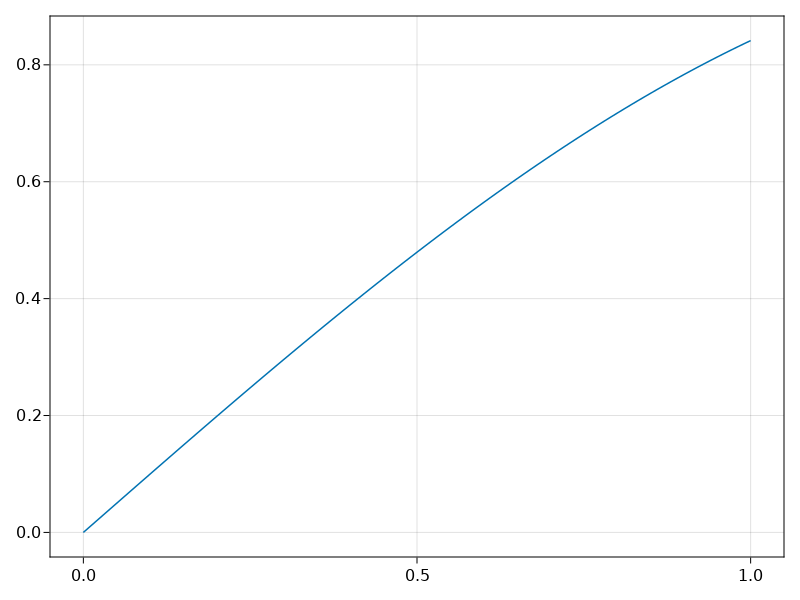

In [29]:
Makie.lines(0:0.01:1, sin.(0:0.01:1))